In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")


In [6]:
features = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "feature_clicks_per_session",
    "engagement_score",
    "days_since_last_login"
]

X = df[features]

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

1. Cluster Distribution

In [11]:
df["cluster"].value_counts()

cluster
2    14478
1    12329
3    12317
0    10876
Name: count, dtype: int64

2. Cluster Profile

In [12]:
cluster_profile = df.groupby("cluster")[features].mean()
cluster_profile

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,engagement_score,days_since_last_login
cluster,,,,,,
0,8.054800,14.645619,45.248520,16.426903,66.249486,17.258735
1,8.413902,13.629173,34.749040,11.357937,54.604163,32.542461
2,7.944882,12.754868,43.438612,10.074665,64.009166,9.148225
3,7.600796,11.813533,57.544759,11.053341,75.225428,30.895673


3. Engagement by Cluster

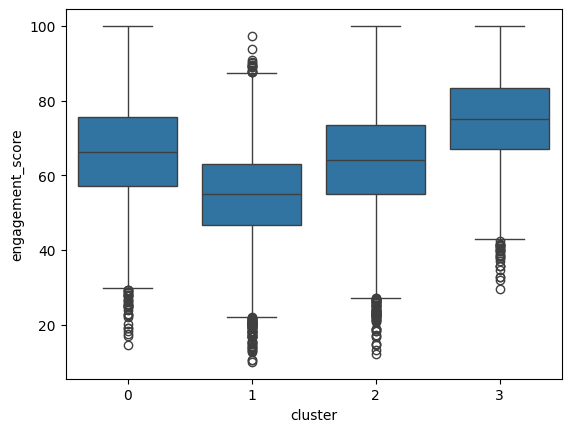

In [13]:
sns.boxplot(data=df, x="cluster", y="engagement_score")
plt.show()

Helps visually compare behavior across clusters.

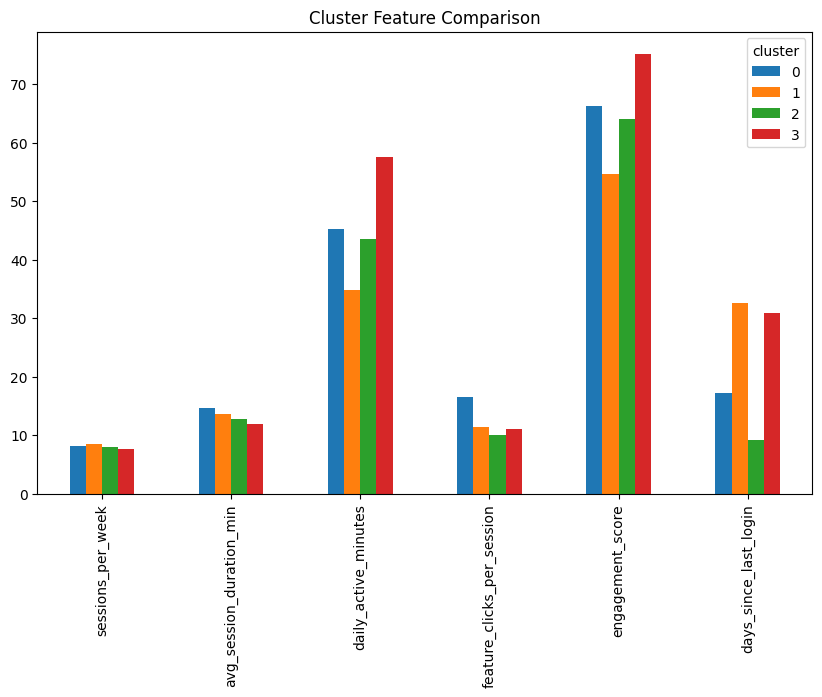

In [14]:
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile.T.plot(kind="bar", figsize=(10,6))
plt.title("Cluster Feature Comparison")
plt.show()

Shows behavioral differences between clusters.

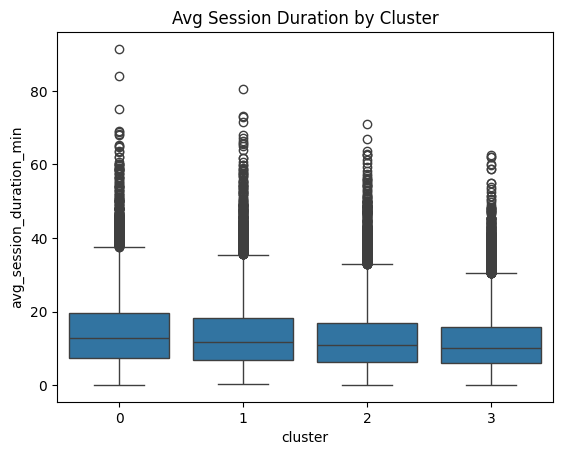

In [16]:
sns.boxplot(data=df, x="cluster", y="avg_session_duration_min")
plt.title("Avg Session Duration by Cluster")
plt.show()

1️ Engagement score

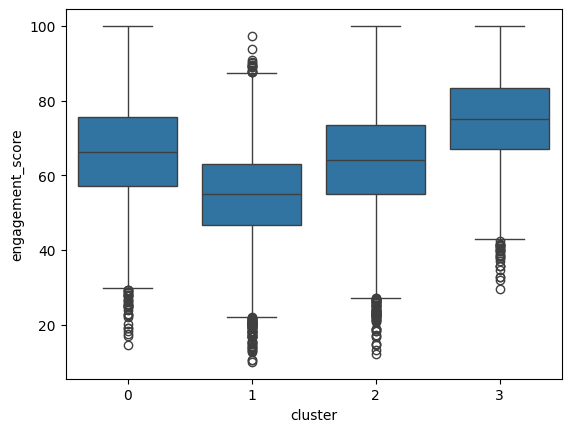

In [17]:
sns.boxplot(data=df, x="cluster", y="engagement_score")
plt.show()

2️ Sessions per week

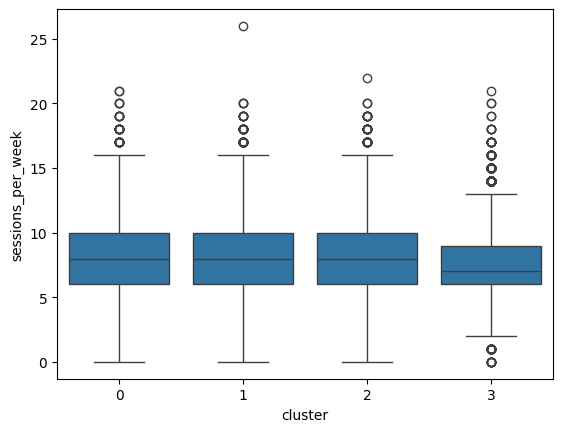

In [18]:
sns.boxplot(data=df, x="cluster", y="sessions_per_week")
plt.show()

3️ Daily active minutes

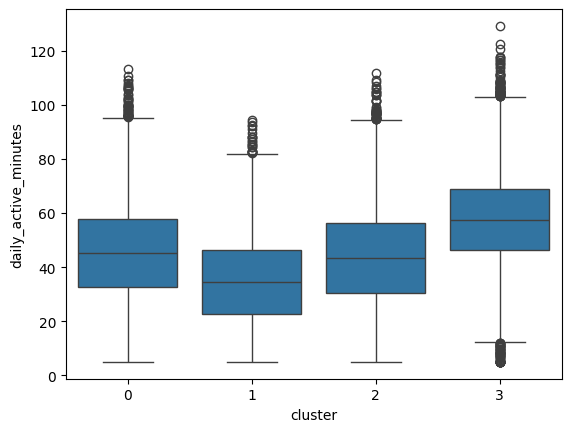

In [19]:
sns.boxplot(data=df, x="cluster", y="daily_active_minutes")
plt.show()

In [20]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source', 'cluster'],
      dtype='str')
